# Fire vs. Non-Fire Image Classification Using a Custom PyTorch Dataset and Pretrained CNN Models

**Name:** Ramirez, Gabriel Mar  **Section:** DS4A  

**Dataset:** Fire Dataset by phylake1337 on Kaggle: https://www.kaggle.com/datasets/phylake1337/fire-dataset

**Label mapping used throughout the notebook:** `0 = Non-Fire`, `1 = Fire`. Fire is the positive class for precision, recall, and F1-score.

## 1. Import Libraries

In [3]:
import sys
import subprocess
import importlib.util

# import name : pip package name
packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "cv2": "opencv-python",
    "torch": "torch",
    "torchvision": "torchvision",
    "sklearn": "scikit-learn",
    "IPython": "ipython",
    "tqdm": "tqdm",
}

missing_packages = []

for import_name, package_name in packages.items():
    if importlib.util.find_spec(import_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    print("Installing missing packages:")
    print(missing_packages)

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_packages
    ])

    print("\nInstallation complete.")
    print("Restart the kernel/runtime if the imports do not work immediately.")
else:
    print("All required packages are already installed.")

Installing missing packages:
['opencv-python']

Installation complete.
Restart the kernel/runtime if the imports do not work immediately.


In [4]:
import os
import gc
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from IPython.display import display
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)

PyTorch: 2.8.0+cpu | torchvision: 0.23.0+cpu


## 2. Dataset Path and Settings

Download the dataset from Kaggle and extract it. `DATASET_ROOT` should point to the extracted folder that contains the two class folders (the next section checks the actual folder names).

Optional, with the Kaggle CLI installed and an API token configured:
```
kaggle datasets download -d phylake1337/fire-dataset --unzip
```

In [5]:
DATASET_ROOT = "fire_dataset"

BATCH_SIZE = 32          # lower to 16 or 8 if you get an out-of-memory error
NUM_EPOCHS = 5
LEARNING_RATE = 0.001
NUM_WORKERS = 0          # 0 is the safest option for Jupyter on Windows
RANDOM_SEED = 42

SAVE_DIR = "saved_models"
REUSE_SAVED_MODELS = False   # True = load saved weights/history instead of retraining (if the files exist)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

## 3. Inspect the Dataset

Check the folder structure first instead of assuming the folder names. The Kaggle download is sometimes extracted with an extra nested folder, so the code looks for the folders that actually contain images.

In [7]:
if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(
        f"'{DATASET_ROOT}' was not found. Download and extract the Kaggle Fire Dataset, "
        "then update DATASET_ROOT in Section 2."
    )

print("Contents of DATASET_ROOT:", os.listdir(DATASET_ROOT))

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

# Find every folder that directly contains image files
image_folders = {}
for folder_path, _, file_names in os.walk(DATASET_ROOT):
    n_images = sum(f.lower().endswith(VALID_EXTENSIONS) for f in file_names)
    if n_images > 0:
        image_folders[folder_path] = n_images

print("\nFolders containing images:")
for folder_path, n_images in image_folders.items():
    print(f"  {folder_path}: {n_images} files")

Contents of DATASET_ROOT: ['fire_dataset']

Folders containing images:
  fire_dataset\fire_dataset\fire_images: 755 files
  fire_dataset\fire_dataset\non_fire_images: 244 files


In [8]:
# Identify the Fire and Non-Fire folders from their names
fire_folders = [p for p in image_folders if "fire" in os.path.basename(p).lower()
                and "non" not in os.path.basename(p).lower()]
non_fire_folders = [p for p in image_folders if "non" in os.path.basename(p).lower()]

if len(fire_folders) != 1 or len(non_fire_folders) != 1:
    raise ValueError(f"Could not identify the class folders automatically.\n"
                     f"Fire candidates: {fire_folders}\nNon-Fire candidates: {non_fire_folders}")

class_folders = {
    "Non-Fire": non_fire_folders[0],
    "Fire": fire_folders[0],
}

class_to_idx = {"Non-Fire": 0, "Fire": 1}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]   # ["Non-Fire", "Fire"]

print("Class folders:", class_folders)
print("class_to_idx:", class_to_idx)

Class folders: {'Non-Fire': 'fire_dataset\\fire_dataset\\non_fire_images', 'Fire': 'fire_dataset\\fire_dataset\\fire_images'}
class_to_idx: {'Non-Fire': 0, 'Fire': 1}


## 4. Create Image Paths and Labels

Same idea as the class example: `X` stores the image paths and `y` stores the numeric labels. Each image is also opened once with OpenCV so that unreadable/corrupted files are skipped instead of crashing training later.

In [9]:
data_dict = {
    "X": [],
    "y": []
}
skipped_files = []

for class_name, folder_path in class_folders.items():
    for file_name in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file_name)
        if not file_name.lower().endswith(VALID_EXTENSIONS):
            skipped_files.append(img_path)
            continue
        if cv2.imread(img_path) is None:
            skipped_files.append(img_path)
            continue
        data_dict["X"].append(img_path)
        data_dict["y"].append(class_to_idx[class_name])

df = pd.DataFrame(data_dict)
df["class_name"] = df["y"].map(idx_to_class)

print("Skipped files (unsupported or unreadable):", len(skipped_files))
for path in skipped_files:
    print("  ", path)

display(df.head())

Skipped files (unsupported or unreadable): 0


,X,y,class_name
0,fire_dataset\fire_dataset\non_fire_images\non_...,0,Non-Fire
1,fire_dataset\fire_dataset\non_fire_images\non_...,0,Non-Fire
2,fire_dataset\fire_dataset\non_fire_images\non_...,0,Non-Fire
3,fire_dataset\fire_dataset\non_fire_images\non_...,0,Non-Fire
4,fire_dataset\fire_dataset\non_fire_images\non_...,0,Non-Fire


Class names: ['Non-Fire', 'Fire']
Total number of images: 999


,Number of images
class_name,
Non-Fire,244
Fire,755


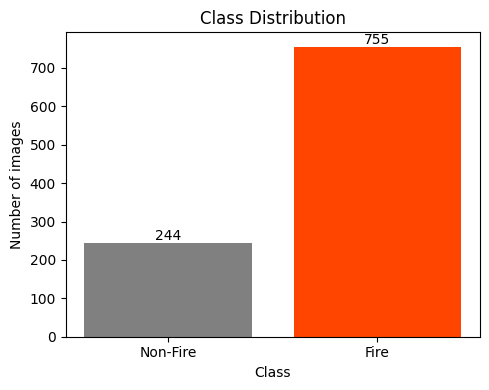

In [10]:
class_counts = df["class_name"].value_counts().reindex(class_names)

print("Class names:", class_names)
print("Total number of images:", len(df))
display(class_counts.to_frame("Number of images"))

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index, class_counts.values, color=["gray", "orangered"])
for i, count in enumerate(class_counts.values):
    plt.text(i, count, str(count), ha="center", va="bottom")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

## 5. Sample Images

Images are converted from BGR (OpenCV) to RGB before displaying.

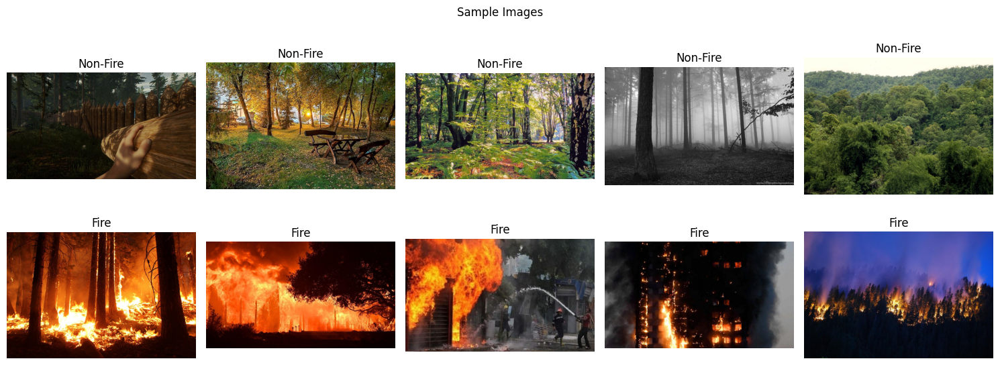

In [11]:
SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(2, SAMPLES_PER_CLASS, figsize=(3 * SAMPLES_PER_CLASS, 6))
for row, class_name in enumerate(class_names):
    samples = df[df["class_name"] == class_name].sample(SAMPLES_PER_CLASS, random_state=RANDOM_SEED)
    for col, img_path in enumerate(samples["X"]):
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

## 6. Train / Validation / Test Split (70% / 15% / 15%)

The data is first split into 70% training and 30% temporary data, and the temporary part is then split in half into validation and test sets. Both splits are stratified by label.

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df["X"], df["y"],
    test_size=0.30,
    stratify=df["y"],
    random_state=RANDOM_SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_SEED,
)

print("Training:  ", len(X_train))
print("Validation:", len(X_val))
print("Testing:   ", len(X_test))

split_table = pd.DataFrame({
    "Training": pd.Series(y_train).map(idx_to_class).value_counts(),
    "Validation": pd.Series(y_val).map(idx_to_class).value_counts(),
    "Testing": pd.Series(y_test).map(idx_to_class).value_counts(),
}).reindex(class_names)
display(split_table)

Training:   699
Validation: 150
Testing:    150


,Training,Validation,Testing
y,,,
Non-Fire,171,36,37
Fire,528,114,113


## 7. Image Transformations

Standard ImageNet preprocessing for pretrained `torchvision` models. `ToTensor()` comes first (as in the class example) because the images come from OpenCV as NumPy arrays; it converts them to `(C, H, W)` tensors with values in [0, 1]. Random augmentation is only used for training.

In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 8. Custom PyTorch Dataset

In [14]:
class CustomDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Could not read image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

## 9. Dataset Objects

In [15]:
train_dataset = CustomDataset(X_train, y_train, transform=train_transforms)
val_dataset = CustomDataset(X_val, y_val, transform=eval_transforms)
test_dataset = CustomDataset(X_test, y_test, transform=eval_transforms)

print("train_dataset:", len(train_dataset))
print("val_dataset:  ", len(val_dataset))
print("test_dataset: ", len(test_dataset))

train_dataset: 699
val_dataset:   150
test_dataset:  150


## 10. DataLoaders

In [16]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

images, labels = next(iter(train_loader))
print("images.shape:", images.shape)   # (batch_size, channels, height, width)
print("labels.shape:", labels.shape)   # (batch_size,)
print("First labels:", [idx_to_class[i] for i in labels[:8].tolist()])

images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])
First labels: ['Non-Fire', 'Fire', 'Fire', 'Fire', 'Non-Fire', 'Non-Fire', 'Fire', 'Non-Fire']


## 11. Device Setup

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


## 12. Load Pretrained Models and Replace the Classification Layer

Each model is loaded with its official ImageNet weights, and its last layer (1,000 outputs) is replaced with a new layer that has 2 outputs (`0 = Non-Fire`, `1 = Fire`). The name of the last layer is different for each architecture:

| Model | Layer replaced |
|---|---|
| ResNet18 / ResNet50 | `model.fc` |
| DenseNet121 | `model.classifier` |
| MobileNetV3 Small | last `nn.Linear` in `model.classifier` (`model.classifier[-1]`) |
| EfficientNet-B0 | last `nn.Linear` in `model.classifier` (`model.classifier[-1]`) |

All layers are fine-tuned (none are frozen).

In [18]:
model_names = [
    "resnet18",
    "resnet50",
    "densenet121",
    "mobilenet_v3_small",
    "efficientnet_b0",
]

display_names = {
    "resnet18": "ResNet18",
    "resnet50": "ResNet50",
    "densenet121": "DenseNet121",
    "mobilenet_v3_small": "MobileNetV3 Small",
    "efficientnet_b0": "EfficientNet-B0",
}


def create_model(model_name, num_classes=2):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model


# Check that every model now outputs 2 classes
dummy_input = torch.zeros(1, 3, 224, 224)
model_info = []
for model_name in model_names:
    model = create_model(model_name)
    model.eval()
    with torch.no_grad():
        output_shape = tuple(model(dummy_input).shape)
    model_info.append({
        "Model": display_names[model_name],
        "Output shape": output_shape,
        "Parameters": sum(p.numel() for p in model.parameters()),
    })
    del model

display(pd.DataFrame(model_info))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:06<00:00, 7.48MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:12<00:00, 8.50MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\User/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


...

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\User/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|█████████████████████████████████████████████████████████████████████████████| 9.83M/9.83M [00:01<00:00, 7.11MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\User/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:02<00:00, 9.32MB/s]


,Model,Output shape,Parameters
0,ResNet18,"(1, 2)",11177538
1,ResNet50,"(1, 2)",23512130
2,DenseNet121,"(1, 2)",6955906
3,MobileNetV3 Small,"(1, 2)",1519906
4,EfficientNet-B0,"(1, 2)",4010110


## 13. Loss Function, Optimizer, and Training Function

Every model uses the same setup: `nn.CrossEntropyLoss()`, Adam with `LEARNING_RATE`, `NUM_EPOCHS` epochs, and the same DataLoaders. `model.train()` is used for the training phase and `model.eval()` with `torch.no_grad()` for the validation phase.

In [19]:
criterion = nn.CrossEntropyLoss()


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch + 1}/{epochs}  ({time.time() - start_time:.1f} s)")
        print(f"  Train Loss: {train_loss:.4f}  |  Train Accuracy: {train_acc:.4f}")
        print(f"  Validation Loss: {val_loss:.4f}  |  Validation Accuracy: {val_acc:.4f}")

    return history

## 14. Train All Five Models

Each model is trained one at a time with the same settings. After training, the weights (`.pth`) and the training history (`.csv`) are saved in `SAVE_DIR`. If `REUSE_SAVED_MODELS = True` and both files already exist, they are loaded instead of retraining.

In [21]:
os.makedirs(SAVE_DIR, exist_ok=True)

trained_models = {}
histories = {}
training_times = {}

for model_name in tqdm(model_names, desc="Training Models", unit="model"):
    print("\n" + "=" * 60)
    print(f"Model: {display_names[model_name]}")
    print("=" * 60)

    weights_path = os.path.join(SAVE_DIR, f"{model_name}_fire_classifier.pth")
    history_path = os.path.join(SAVE_DIR, f"{model_name}_history.csv")

    # same starting point for the new layer of every model
    torch.manual_seed(RANDOM_SEED)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(RANDOM_SEED)

    model = create_model(model_name, num_classes=2)
    model = model.to(device)

    if REUSE_SAVED_MODELS and os.path.exists(weights_path) and os.path.exists(history_path):
        # load the saved model instead of retraining
        model.load_state_dict(torch.load(weights_path, map_location=device))
        history = pd.read_csv(history_path).to_dict(orient="list")
        training_times[model_name] = np.nan
        tqdm.write(f"Loaded saved weights from {weights_path}")
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        start_time = time.time()
        history = train_model(model, train_loader, val_loader, criterion, optimizer, device, NUM_EPOCHS)
        training_times[model_name] = time.time() - start_time

        torch.save(model.state_dict(), weights_path)
        pd.DataFrame(history).to_csv(history_path, index=False)
        tqdm.write(f"Training time: {training_times[model_name]:.1f} s | saved to {weights_path}")

        # free the optimizer's memory before training the next model
        del optimizer
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    trained_models[model_name] = model
    histories[model_name] = history

Training Models:   0%|          | 0/5 [00:00<?, ?model/s]


Model: ResNet18
Epoch 1/5  (66.9 s)
  Train Loss: 0.2437  |  Train Accuracy: 0.9242
  Validation Loss: 7.4001  |  Validation Accuracy: 0.9067
Epoch 2/5  (64.9 s)
  Train Loss: 0.1417  |  Train Accuracy: 0.9371
  Validation Loss: 0.1845  |  Validation Accuracy: 0.9333
Epoch 3/5  (67.1 s)
  Train Loss: 0.0994  |  Train Accuracy: 0.9614
  Validation Loss: 0.0627  |  Validation Accuracy: 0.9733
Epoch 4/5  (65.8 s)
  Train Loss: 0.0745  |  Train Accuracy: 0.9728
  Validation Loss: 0.0619  |  Validation Accuracy: 0.9733
Epoch 5/5  (65.4 s)
  Train Loss: 0.0474  |  Train Accuracy: 0.9857
  Validation Loss: 0.0965  |  Validation Accuracy: 0.9533
Training time: 330.2 s | saved to saved_models\resnet18_fire_classifier.pth

Model: ResNet50
Epoch 1/5  (138.8 s)
  Train Loss: 0.2353  |  Train Accuracy: 0.9385
  Validation Loss: 1.6706  |  Validation Accuracy: 0.8667
Epoch 2/5  (136.4 s)
  Train Loss: 0.1156  |  Train Accuracy: 0.9571
  Validation Loss: 0.0724  |  Validation Accuracy: 0.9800
Epoch 

## 15. Test Inference Function

In [22]:
def evaluate_model(model, test_loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.tolist())
            y_pred.extend(predictions.cpu().tolist())

    return y_true, y_pred


test_predictions = {}
for model_name, model in trained_models.items():
    y_true, y_pred = evaluate_model(model, test_loader, device)
    test_predictions[model_name] = (y_true, y_pred)
    print(f"{display_names[model_name]:<18} {len(y_pred)} test predictions")

ResNet18           150 test predictions
ResNet50           150 test predictions
DenseNet121        150 test predictions
MobileNetV3 Small  150 test predictions
EfficientNet-B0    150 test predictions


## 16. Accuracy, Precision, Recall, and F1-Score

Precision, recall, and F1-score are calculated for the **Fire** class (`pos_label=1`, `average="binary"`). `zero_division=0` avoids a warning if a model never predicts Fire.

In [23]:
results = []

for model_name, (y_true, y_pred) in test_predictions.items():
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)

    results.append({
        "Model": display_names[model_name],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    })

## 17. Model Comparison Table

In [24]:
results_df = pd.DataFrame(results).round(4)
results_df["Training Time (s)"] = [round(training_times[m], 1) for m in test_predictions]

display(results_df)
results_df.to_csv("fire_model_results.csv", index=False)
print("Saved to fire_model_results.csv")

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,ResNet18,0.9733,0.9910,0.9735,0.9821,330.2
1,ResNet50,0.9800,0.9825,0.9912,0.9868,685.7
2,DenseNet121,0.9467,0.9907,0.9381,0.9636,621.4
3,MobileNetV3 Small,0.9667,0.9576,1.0000,0.9784,160.7
4,EfficientNet-B0,0.9600,0.9908,0.9558,0.9730,335.6


Saved to fire_model_results.csv


## 18. Classification Reports

`target_names=["Non-Fire", "Fire"]` matches the label mapping `0 = Non-Fire`, `1 = Fire`.

In [25]:
for model_name, (y_true, y_pred) in test_predictions.items():
    print("=" * 60)
    print(display_names[model_name])
    print("=" * 60)
    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Non-Fire", "Fire"],
        digits=4,
        zero_division=0,
    ))

ResNet18
              precision    recall  f1-score   support

    Non-Fire     0.9231    0.9730    0.9474        37
        Fire     0.9910    0.9735    0.9821       113

    accuracy                         0.9733       150
   macro avg     0.9570    0.9732    0.9648       150
weighted avg     0.9742    0.9733    0.9736       150

ResNet50
              precision    recall  f1-score   support

    Non-Fire     0.9722    0.9459    0.9589        37
        Fire     0.9825    0.9912    0.9868       113

    accuracy                         0.9800       150
   macro avg     0.9773    0.9685    0.9728       150
weighted avg     0.9799    0.9800    0.9799       150

DenseNet121
              precision    recall  f1-score   support

    Non-Fire     0.8372    0.9730    0.9000        37
        Fire     0.9907    0.9381    0.9636       113

    accuracy                         0.9467       150
   macro avg     0.9139    0.9555    0.9318       150
weighted avg     0.9528    0.9467    0.9479 

## 19. Confusion Matrices

Rows = actual class, columns = predicted class.

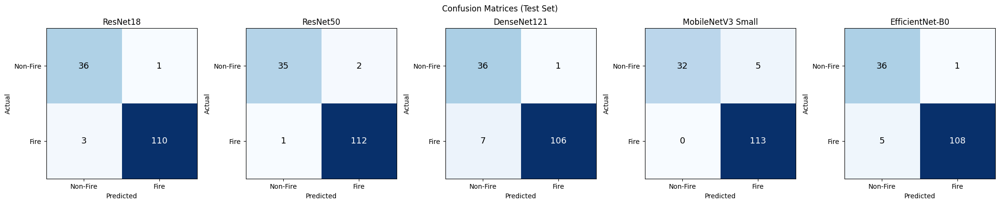

In [26]:
fig, axes = plt.subplots(1, len(test_predictions), figsize=(4.2 * len(test_predictions), 4.2))

for ax, (model_name, (y_true, y_pred)) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-Fire", "Fire"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Non-Fire", "Fire"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(display_names[model_name])

plt.suptitle("Confusion Matrices (Test Set)")
plt.tight_layout()
plt.show()

## 20. Model Comparison Bar Chart

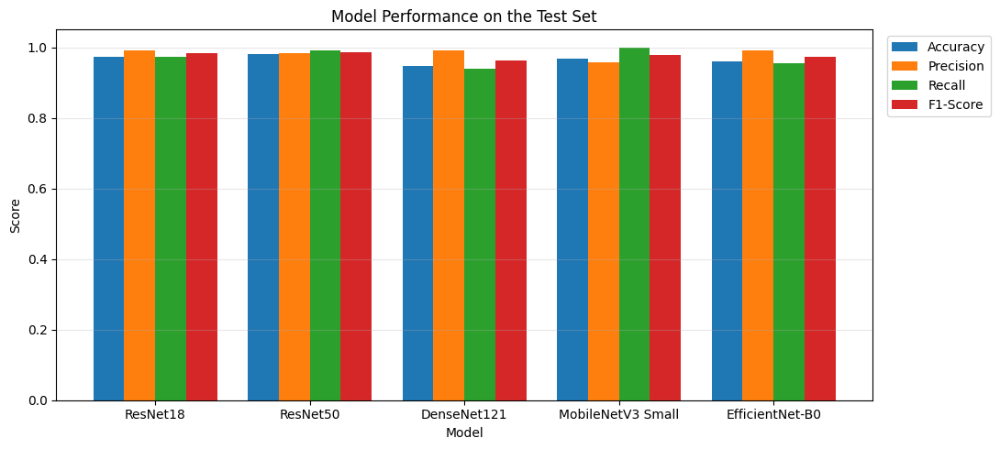

In [27]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x_positions = np.arange(len(results_df))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metric_names):
    ax.bar(x_positions + (i - 1.5) * bar_width, results_df[metric], width=bar_width, label=metric)

ax.set_xticks(x_positions)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Performance on the Test Set")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Training History

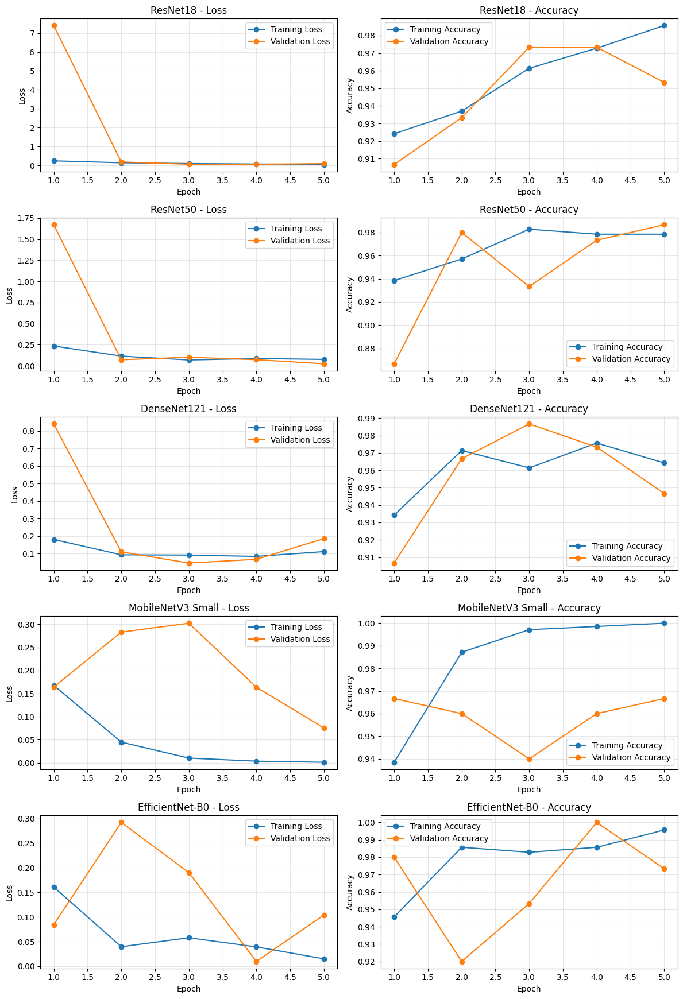

In [28]:
fig, axes = plt.subplots(len(histories), 2, figsize=(12, 3.5 * len(histories)))

for row, (model_name, history) in enumerate(histories.items()):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    axes[row, 0].plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
    axes[row, 0].plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
    axes[row, 0].set_title(f"{display_names[model_name]} - Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
    axes[row, 1].plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
    axes[row, 1].set_title(f"{display_names[model_name]} - Accuracy")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Accuracy")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Sample Predictions

The same randomly selected test images are shown for every model. Confidence is the softmax probability of the predicted class.

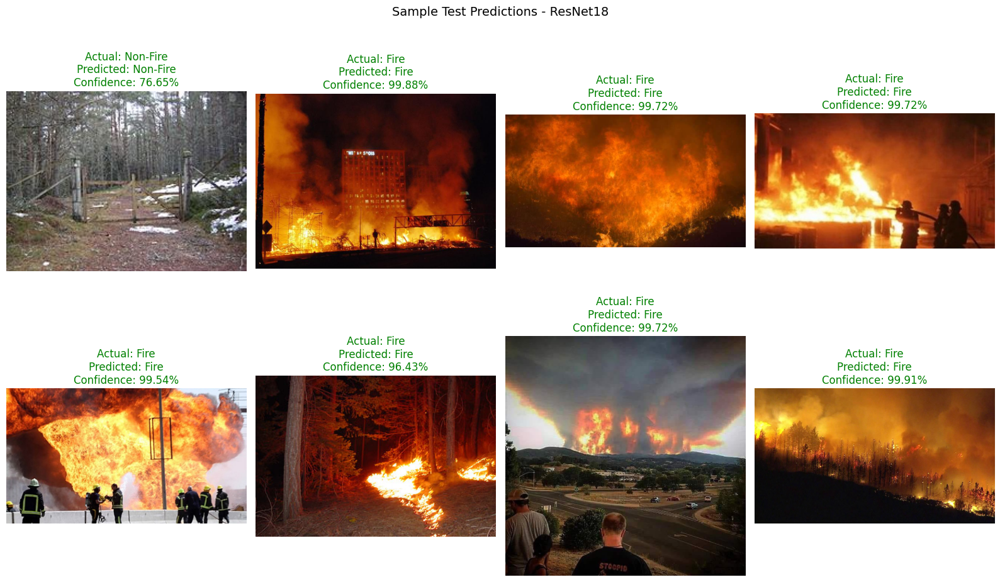

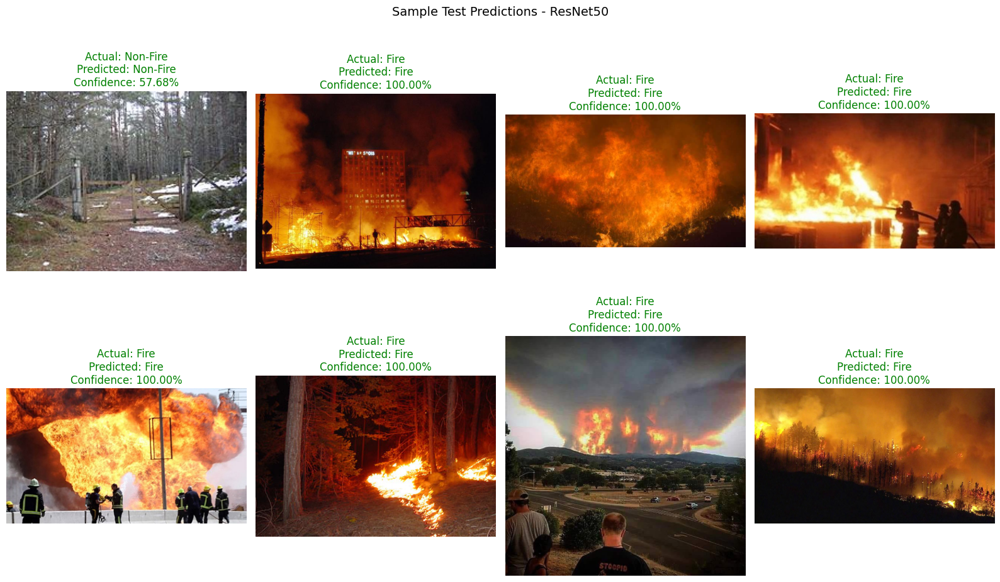

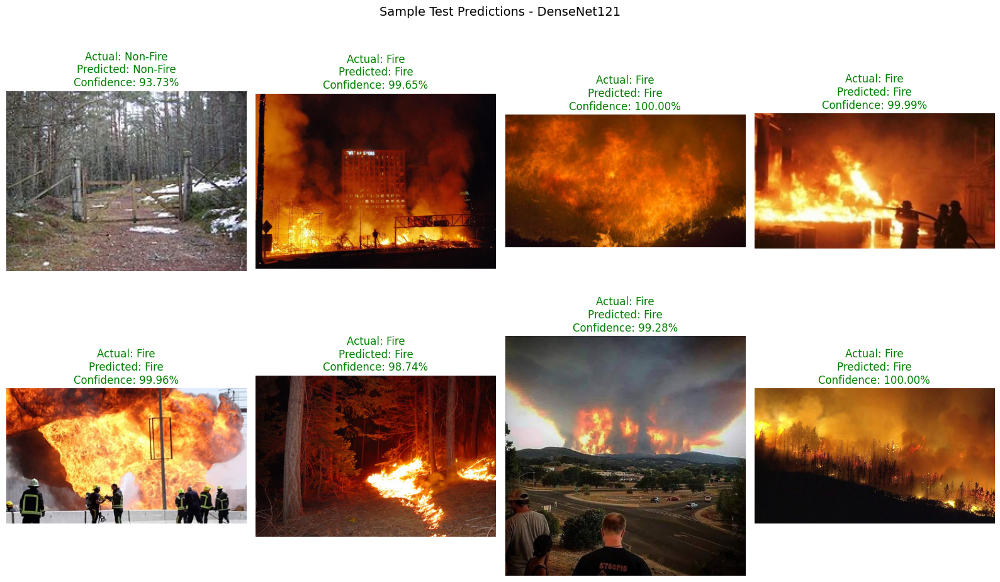

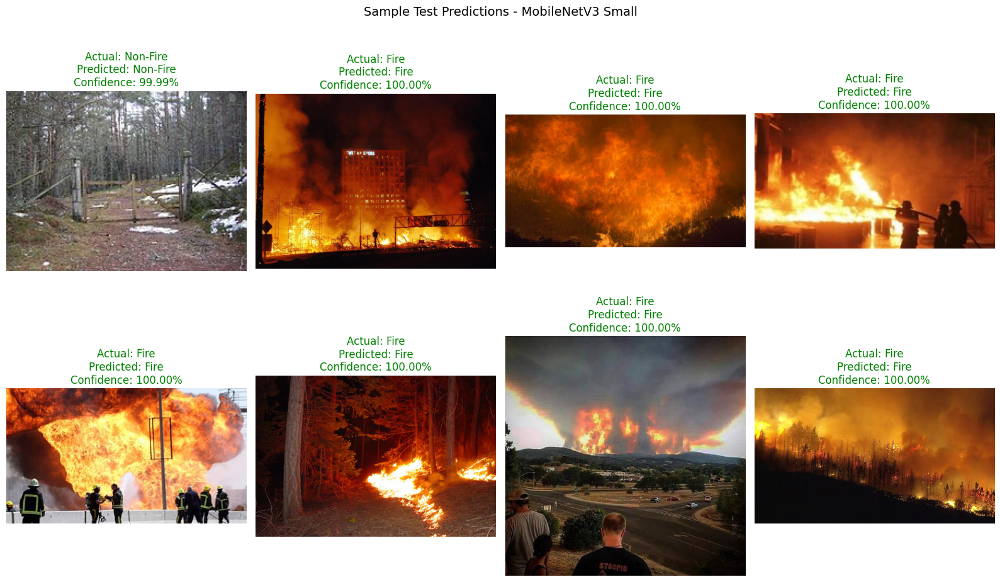

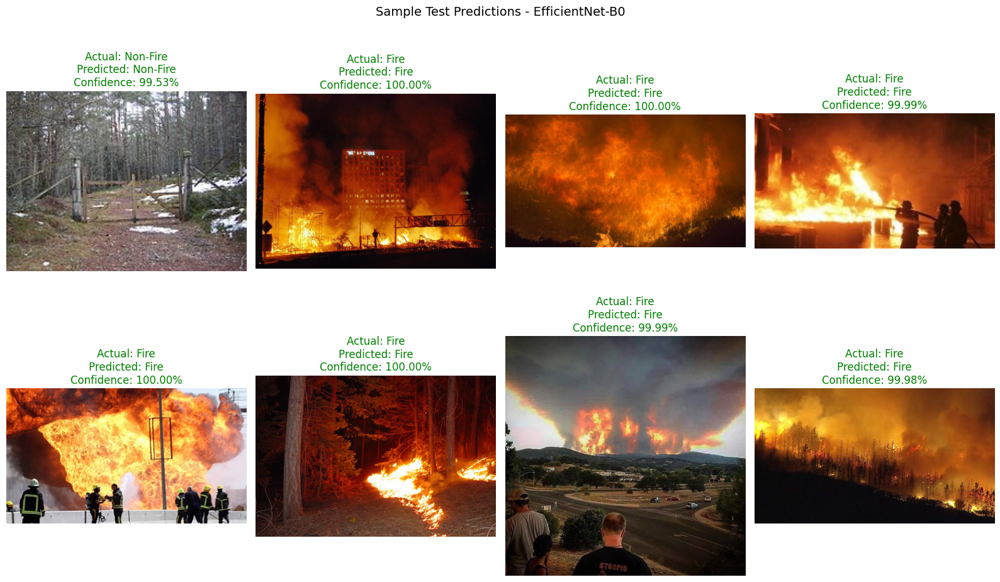

In [29]:
N_SAMPLES = 8
sample_indices = random.Random(RANDOM_SEED).sample(range(len(test_dataset)), min(N_SAMPLES, len(test_dataset)))

for model_name, model in trained_models.items():
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(16, 10))
    axes = axes.flatten()

    for ax, idx in zip(axes, sample_indices):
        image, label = test_dataset[idx]
        with torch.no_grad():
            outputs = model(image.unsqueeze(dim=0).to(device))
            probabilities = torch.softmax(outputs, dim=1)
        predicted = torch.argmax(outputs, dim=1).item()
        confidence = probabilities[0, predicted].item()

        original = cv2.cvtColor(cv2.imread(test_dataset.image_paths[idx]), cv2.COLOR_BGR2RGB)
        ax.imshow(original)
        ax.set_title(f"Actual: {idx_to_class[label.item()]}\n"
                     f"Predicted: {idx_to_class[predicted]}\n"
                     f"Confidence: {confidence:.2%}",
                     color="green" if predicted == label.item() else "red")
    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Sample Test Predictions - {display_names[model_name]}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 23. Analysis and Interpretation of Results

### 23.1 Overall Performance

All five fine-tuned models reached a test accuracy between 94.67% (DenseNet121) and 98.00% (ResNet50), which means that even the weakest model made only 8 mistakes out of 150 test images. Since the dataset is imbalanced, these numbers need a reference point first. The test set contains 113 Fire and 37 Non-Fire images, so a useless "model" that always answers *Fire* would already get 75.33% accuracy while recognizing zero Non-Fire images. Our models are roughly 20 percentage points above that baseline, and each of them correctly classified at least 32 of the 37 Non-Fire images. So the high accuracy is not just a side effect of predicting the majority class, although the imbalance still means accuracy cannot be the only metric we look at.

Reaching this level with only 699 training images and 5 epochs is mainly a result of transfer learning. The networks did not have to learn how to "see" from scratch: their ImageNet-pretrained layers already detect edges, colors, textures, and object shapes, and fine-tuning only had to adapt these features to the Fire vs. Non-Fire decision. Fire also has fairly strong visual cues, such as bright orange and yellow regions, glowing areas, and smoke textures, which are exactly the kind of low- and mid-level patterns that pretrained CNN features respond to. This likely explains why five very different architectures all ended up in the same high range. The more interesting part of the experiment is therefore not *whether* the models work, but *how* they differ: which errors they make, what they cost to train, and how stable their training was.

### 23.2 Interpretation of Each Model

**ResNet18** correctly detected 110 of 113 Fire images and raised only one false alarm, giving 97.33% accuracy, 99.10% Fire precision, and 97.35% Fire recall. What stands out is how *balanced* its errors are: it was almost equally good on both classes (97.35% Fire recall and 97.30% Non-Fire recall). Because of this, its macro-average recall (0.9732, the average recall of the two classes, also called balanced accuracy) is actually the highest of all five models, slightly above ResNet50's 0.9685. Its residual (skip) connections let each block learn only a correction to its input, which makes the network easy to optimize, and 18 layers of pretrained features were clearly enough for a two-class problem with strong color and texture cues. With about 11.18M parameters and 330.2 s of training, this result shows that a deeper network is not automatically necessary. Its validation accuracy peaked at 97.33% in epochs 3 and 4 and dropped to 95.33% at epoch 5, while its training accuracy kept rising to 98.57% and its validation loss increased from 0.0619 to 0.0965. This could be an early sign of overfitting, but the drop is only 3 validation images in a single epoch, so it is not strong evidence.

The deeper **ResNet50** obtained the best overall test result: 98.00% accuracy, the highest Fire F1-score (0.9868), and the highest macro F1-score (0.9728). It missed only one Fire image and produced two false alarms, for three errors in total. Its bottleneck residual blocks give it considerably more depth and representational capacity, which may help with harder cases such as small or partly hidden flames. It also had a smooth ending to training: epoch 5 gave both its best validation accuracy (98.67%) and its lowest validation loss (0.0245), so the final-epoch weights we tested happened to be its best ones. However, the improvement is expensive. ResNet50 has 23.51M parameters (about 2.1× ResNet18) and needed 685.7 s of training, about 2.1× ResNet18 and 4.3× MobileNetV3 Small. Compared with ResNet18, all this extra computation bought **one** fewer mistake on the test set (3 vs. 4), and it traded two fewer missed fires for one more false alarm. This is a clear example of diminishing returns: more capacity helped a little, but much less than proportionally to its cost.

**DenseNet121** had the lowest accuracy (94.67%), even though its design (each layer receiving the feature maps of all earlier layers in its block) is often described as more advanced than ResNet. Its errors were very one-sided: 7 Fire images were missed, but only 1 Non-Fire image was wrongly flagged. This gives a very high Fire precision (99.07%) but the lowest Fire recall (93.81%). In other words, DenseNet121 was conservative about predicting Fire: when it said "fire", it was almost always right, but it needed stronger evidence before saying so, and some real fires did not reach that level. The same errors appear from the other side as a Non-Fire precision of only 83.72%, because 7 of the 43 images it labelled Non-Fire actually contained fire. The training log gives a useful clue about this result. Validation accuracy peaked at 98.67% in epoch 3 (validation loss 0.0472) and then fell to 94.67% by epoch 5, but **training accuracy also dropped** in the last epoch (97.57% → 96.42%) and training loss went up (0.0848 → 0.1122). Classic overfitting usually looks different: training keeps improving while validation gets worse. A decline in both at once points more toward an unstable final update, which could be related to fine-tuning all layers with a learning rate of 0.001, although this experiment cannot confirm the exact cause. In this setup, the result may therefore say more about how DenseNet121 responded to our training settings than about the architecture's ability on this task.

**MobileNetV3 Small** was the only model that detected **all 113 Fire images** (100% Fire recall), but it also produced the most false alarms: 5 of the 37 Non-Fire images were classified as Fire. This gives 96.67% accuracy, 95.76% Fire precision, and a 97.84% Fire F1-score. All of its errors go in the same direction, so it clearly leans toward predicting Fire, which is the opposite behavior from DenseNet121. At the same time, it is by far the most efficient model: 1.52M parameters and 160.7 s of training (about 32 s per epoch). It achieves this with depthwise separable convolutions and other lightweight blocks designed for mobile hardware, which makes it attractive for embedded cameras, edge devices, or real-time monitoring. Its training behavior needs some care, though. Training loss dropped to 0.0013 and training accuracy reached 100%, so the model fit its training images almost perfectly, while validation accuracy stayed between 94% and 96.67%. The train-validation gap was largest at epoch 3 (5.7 points) and then *narrowed* to 3.3 points, and the best validation loss (0.0756) came at the final epoch. So the evidence for memorization is the near-zero training loss and the persistent gap, not a gap that kept growing. The model did not get worse on validation data by the end, and its test result stayed strong, but training for more epochs could make overfitting a bigger risk.

**EfficientNet-B0** reached 96.00% accuracy with 99.08% Fire precision and 95.58% Fire recall. It made one false alarm and missed 5 fires, so it shares DenseNet121's conservative tendency, but less strongly. EfficientNet's main idea is compound scaling: instead of only making a network deeper, the family scales depth, width, and input resolution together, and B0 is the smallest base version. With 4.01M parameters, it is much smaller than the ResNets, but its training time (335.6 s) was almost the same as ResNet18's (330.2 s), even though it has only about 36% of ResNet18's parameters. Its validation accuracy moved a lot between epochs (98.00% → 92.00% → 95.33% → **100.00%** → 97.33%), and it then scored 96.00% on the test set. The 100% at epoch 4 therefore should not be read as perfect generalization: on 150 validation images, 100% versus 97.33% is only a difference of 4 images. Efficient scaling makes EfficientNet a strong design in terms of accuracy per parameter, but that does not guarantee the top result on every dataset, especially with a short training schedule and one set of hyperparameters shared by all models.

### 23.3 Architecture, Complexity, and Performance

When the models are ranked by size and by accuracy, the two rankings do not match. By parameter count the order is ResNet50 > ResNet18 > DenseNet121 > EfficientNet-B0 > MobileNetV3 Small, while by test accuracy it is ResNet50 > ResNet18 > MobileNetV3 Small > EfficientNet-B0 > DenseNet121. The smallest model (MobileNetV3 Small) outperformed two larger ones, and the model with dense feature reuse came last. Concretely, ResNet50 has about **15.5 times** as many parameters as MobileNetV3 Small and took about **4.3 times** as long to train, but its accuracy is only **1.33 percentage points** higher, which is **2 more correct images out of 150**. Compared with ResNet18, doubling the parameters and training time improved accuracy by 0.67 points, which is **one** image. Extra capacity was not useless (ResNet50 did make the fewest errors), but the benefit was small compared with the extra cost. For a deployed system, the question is whether 1-2 more correct images per 150 are worth 2-4 times more computation, and the answer depends on the hardware and the application.

The training times also show that **parameter count is not the same as computational cost**. DenseNet121 has only 62% of ResNet18's parameters, yet it took about 1.9× longer to train (621.4 s vs. 330.2 s). EfficientNet-B0 has about a third of ResNet18's parameters but took the same time. Parameter count measures how much the model has to store, while speed also depends on how many operations are performed and how much data moves through memory. DenseNet's concatenations produce large feature maps, and the depthwise convolutions in MobileNet/EfficientNet are not always as fast on a CPU as their low parameter count suggests. This means that if speed matters, it should be measured directly rather than estimated from model size.

### 23.4 Input Requirements and the Shared Pipeline

Every model received the same input: RGB images (converted from OpenCV's BGR format), resized to 224 × 224, and normalized with the ImageNet mean and standard deviation. This matters because the pretrained weights were learned on images with exactly those statistics. If the channels were in the wrong order or the pixel values had a different scale, the early layers would receive inputs unlike anything they saw during pretraining, and fine-tuning would start from a much worse position. Using one pipeline for all models also makes the comparison fairer: since the data, split, preprocessing, optimizer, learning rate, and number of epochs were identical, the differences in results are more likely to come from the architectures and how they responded to training rather than from different data handling.

The shared setup is also a limitation. A single learning rate and a simple `Resize((224, 224))`, which stretches images instead of using each model's official resize-and-crop, are a common middle ground but not necessarily ideal for every architecture. Since all layers were fine-tuned, the models could adapt to this input, but with architecture-specific tuning (for example, a different learning rate for DenseNet121 or EfficientNet-B0), the ranking could change.

### 23.5 Effect of Class Imbalance

About **75.6%** of the images are Fire and only **24.4%** are Non-Fire, and this affects how every metric should be read. The test set has 113 Fire images but only 37 Non-Fire images, so each Non-Fire mistake changes Non-Fire recall by about 2.7 percentage points, while each Fire mistake changes Fire recall by less than 0.9 points. Overall accuracy and weighted averages are dominated by the Fire class, which is why every model's weighted F1 is at least 0.9479, while its Non-Fire scores can be clearly weaker: DenseNet121's Non-Fire precision is 83.72%, EfficientNet-B0's is 87.80%, and MobileNetV3 Small's Non-Fire recall is only 86.49%. Looking only at the Fire metrics or the weighted averages would hide these weaknesses.

The macro averages, which give both classes equal weight, show this more clearly. Macro F1 ranks the models ResNet50 (0.9728) > ResNet18 (0.9648) > MobileNetV3 Small (0.9529) > EfficientNet-B0 (0.9480) > DenseNet121 (0.9318), while macro recall (balanced accuracy) ranks ResNet18 first (0.9732) and MobileNetV3 Small last (0.9324). MobileNetV3 Small looks excellent if we only check Fire recall, but it is the weakest model when both classes are treated as equally important. Interestingly, the imbalance did not push every model in the same direction: MobileNetV3 Small leaned toward Fire, but DenseNet121 and EfficientNet-B0 mostly erred toward Non-Fire. So the imbalance alone does not explain the error patterns, although it may still influence the models' decision tendencies. Future experiments could use class weights in `CrossEntropyLoss`, oversampling or a balanced sampler for the Non-Fire class, more Non-Fire images in general, and especially more "hard negatives" (scenes that look similar to fire, such as sunsets, orange lights, or lamps) to test whether the models rely on real fire features or just on warm colors.

### 23.6 Training and Validation Curves

A few patterns are common to several models. In the first epoch, the validation **loss** of some models was very high (7.4001 for ResNet18, 1.6706 for ResNet50) even though validation **accuracy** was still 86-91%. A high loss together with a decent accuracy means that a small number of images were predicted wrongly with extreme confidence. Such early spikes are possible when all pretrained layers are updated with a relatively large learning rate, although we cannot confirm this as the cause. The losses dropped sharply after epoch 1 for both models. We also noticed that validation accuracy was sometimes *higher* than training accuracy in early epochs (EfficientNet-B0: 98.00% vs. 94.56% in epoch 1). This is not a contradiction: training accuracy is measured while the weights are still changing, in training mode, and on randomly flipped images, while validation is measured after the epoch with the model in evaluation mode.

The curves also fluctuate noticeably from epoch to epoch. With 150 validation images, one image equals 0.67 percentage points, so EfficientNet-B0's jump from 92.00% to 100.00% corresponds to 12 images, and single-epoch changes should not be over-interpreted. More importantly, our test results come from the **final-epoch** weights of each model, and epoch 5 was not the best validation epoch for every model. It was the best for ResNet50 (lowest validation loss, 0.0245), but not for DenseNet121 (best at epoch 3), ResNet18 (lowest validation loss at epoch 4), or EfficientNet-B0 (best at epoch 4). Part of the final comparison may therefore reflect *where each model's fluctuations happened to land at epoch 5* rather than purely architectural differences. Saving the checkpoint with the best validation loss, early stopping, a learning-rate scheduler, or simply a smaller learning rate for fine-tuning would make the comparison more reliable, while the test set would still stay independent.

### 23.7 Statistical Caution

Because the test set is small, the differences between models are only a few images: ResNet50 made 3 mistakes, ResNet18 4, MobileNetV3 Small 5, EfficientNet-B0 6, and DenseNet121 8. The gap between the two best models, 98.00% vs. 97.33%, is a **single image**. As a rough check, we computed approximate 95% confidence intervals for accuracy from these counts (Wilson intervals): about 94.3%-99.3% for ResNet50 and about 89.8%-97.3% for DenseNet121. All five models' intervals overlap. This means the experiment clearly shows that all five models perform well above the baseline, but it does not prove that one architecture will always beat another on this task. Stronger evidence would need a larger and more diverse test set (including images from other environments), repeated training with different random seeds, cross-validation, and a paired statistical test such as McNemar's test on the per-image predictions of two models.

## 24. Practical Interpretation of Classification Errors

In a fire-detection setting, the two Fire metrics answer two practical questions. **Fire precision** asks: *when the system says there is a fire, how often is it right?* **Fire recall** asks: *out of all the real fires, how many did the system catch?* A **false negative** (Fire → predicted Non-Fire) means a real fire goes unnoticed, which in an early-warning system could delay the response to a dangerous situation. A **false positive** (Non-Fire → predicted Fire) means an unnecessary alarm. One false alarm is only an inconvenience, but frequent false alarms can cause alarm fatigue, where people start ignoring or switching off the system, and then even correct alarms lose their value. For a safety-critical detector, missing a fire is usually the more serious error, but the false-alarm rate cannot be ignored either.

| Model | Missed fires (FN) | False alarms (FP) | Total errors | Fires missed (of 113) | Non-Fire scenes flagged (of 37) |
|---|---:|---:|---:|---:|---:|
| ResNet18 | 3 | 1 | 4 | 2.7% | 2.7% |
| ResNet50 | 1 | 2 | 3 | 0.9% | 5.4% |
| DenseNet121 | 7 | 1 | 8 | 6.2% | 2.7% |
| MobileNetV3 Small | 0 | 5 | 5 | 0.0% | 13.5% |
| EfficientNet-B0 | 5 | 1 | 6 | 4.4% | 2.7% |

The contrast between MobileNetV3 Small and DenseNet121 shows why accuracy alone is not enough. Trained on the same data, they developed opposite behaviors: MobileNetV3 Small missed **no** fires but flagged 5 Non-Fire scenes, while DenseNet121 flagged only 1 Non-Fire scene but missed **7** fires. Their total error counts (5 and 8) are much closer than their practical consequences. For an early-warning system, MobileNetV3 Small's error profile is probably preferable; for a system where false alarms are costly (for example, automatic sprinklers or emergency calls), DenseNet121's caution would matter more. The table also shows something the precision values hide. MobileNetV3 Small flagged **13.5%** of the Non-Fire scenes it saw, five times the rate of most other models. In a real camera feed, most frames contain no fire (the opposite of our 75%-Fire dataset), so this rate would produce many more false alarms in practice than its 95.76% precision suggests. Finally, all these results use the default decision rule (predict the class with the higher softmax probability). Changing the probability threshold for "Fire" could move a model toward higher recall or higher precision, so part of this trade-off could be adjusted for a specific application.

## 25. Key Inferences from the Experiment

1. **Transfer learning did most of the work.** With only 699 training images and 5 epochs, every pretrained architecture exceeded 94% accuracy and beat the 75% "always Fire" baseline by about 20 points, showing that ImageNet features transfer well to fire recognition.
2. **More complexity gave clearly diminishing returns.** ResNet50 needed about 15× the parameters and 4× the training time of MobileNetV3 Small for 2 more correct test images, and about 2× the cost of ResNet18 for 1 more correct image.
3. **Parameter count is not a reliable estimate of computational cost.** DenseNet121 has fewer parameters than ResNet18 but took almost twice as long to train, so speed should be measured rather than assumed from model size.
4. **Models with similar accuracy can behave very differently.** MobileNetV3 Small tended to predict Fire (0 misses, 5 false alarms), while DenseNet121 and EfficientNet-B0 tended to predict Non-Fire (7 and 5 misses, 1 false alarm each). The confusion matrices reveal this; the accuracy column does not.
5. **The "best" model depends on the metric and the goal.** ResNet50 leads in accuracy and macro F1, ResNet18 leads in balanced accuracy, MobileNetV3 Small leads in Fire recall and efficiency, and DenseNet121/EfficientNet-B0 lead in Fire precision.
6. **Class imbalance makes class-specific and macro metrics essential.** Weighted scores stay high for every model, while Non-Fire precision or recall drops as low as 83.72% and 86.49%.
7. **Validation accuracy on a small set is a noisy guide, and the last epoch is not always the best one.** EfficientNet-B0 reached 100% validation accuracy but 96% on the test set, and three of the five models had their best validation epoch before epoch 5.

## 26. Limitations

The dataset is small (999 images) and imbalanced (about 3 Fire images for every Non-Fire image), and the test set contains only 150 images, including just 37 Non-Fire images. As a result, one image changes the accuracy by 0.67 points and the Non-Fire recall by 2.7 points, and the differences between models are within the uncertainty of the measurement. Each model was trained only once, with one random seed, for 5 epochs, using one learning rate and a simple resize shared by all architectures, and the final-epoch weights were tested instead of the best validation checkpoint. Other settings or repeated runs could change the ranking. The training times were measured on a single CPU and are only meaningful relative to each other. Finally, we did not check for near-duplicate images, such as several photos of the same scene, across the training and test sets. If such duplicates exist, the test scores could be slightly optimistic.

## 27. Conclusion

This experiment showed that ImageNet-pretrained CNNs can be fine-tuned into accurate fire detectors with less than a thousand images and only five epochs of training on a CPU. All five architectures reached 94.67%-98.00% test accuracy, well above the 75% that the class imbalance would give for free, which confirms that general visual features learned on ImageNet transfer well to this task. The models still differed, and the differences come from several sources at once: architecture and capacity, how each network responded to the shared training settings (visible in the unstable last epoch of DenseNet121 and the near-perfect training fit of MobileNetV3 Small), and the natural variation of evaluating on a small, imbalanced test set.

In this experiment, **ResNet50** achieved the strongest overall test results, with 98.00% accuracy, the highest Fire and macro F1-scores, and only 3 errors. However, **ResNet18** came within one image of it at half the parameters and training time and had the most balanced performance across both classes. **MobileNetV3 Small** detected every fire at a fraction of the computational cost, but it produced the most false alarms. **DenseNet121** was very precise when it predicted Fire but missed the most real fires, and **EfficientNet-B0** combined high precision with moderate cost without reaching the top accuracy under this particular training setup. None of these models is the best in every respect. A safety-oriented early-warning system would favor high Fire recall, a device with limited resources would favor efficiency, a system where false alarms are expensive would favor precision, and a general benchmark would look at balanced metrics such as macro F1 and balanced accuracy.

The main lesson is that accuracy alone does not describe a classifier well, especially with imbalanced data and real consequences attached to each type of error. The confusion matrices, class-specific metrics, and training curves told us much more about how each model behaves than the accuracy column did. More generally, the experiment shows an important principle of deep learning: **a larger or more complex neural network does not automatically produce a proportionally better model.** Whether a model is suitable depends on its architecture, the data, the training conditions, the available computational resources, and the actual consequences of its classification errors.